<div style="background-color: #E8FFFF; padding: 30px; border-radius: 12px; border-left: 8px solid #00F0FF; border-right: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2); text-align: center;">
    <h1 style="color: #005F73; margin: 0; text-shadow: 0 0 10px rgba(0, 240, 255, 0.9); font-size: 36px; font-weight: bold;">✈️ European Flights EDA (2016-2022)</h1>
</div>

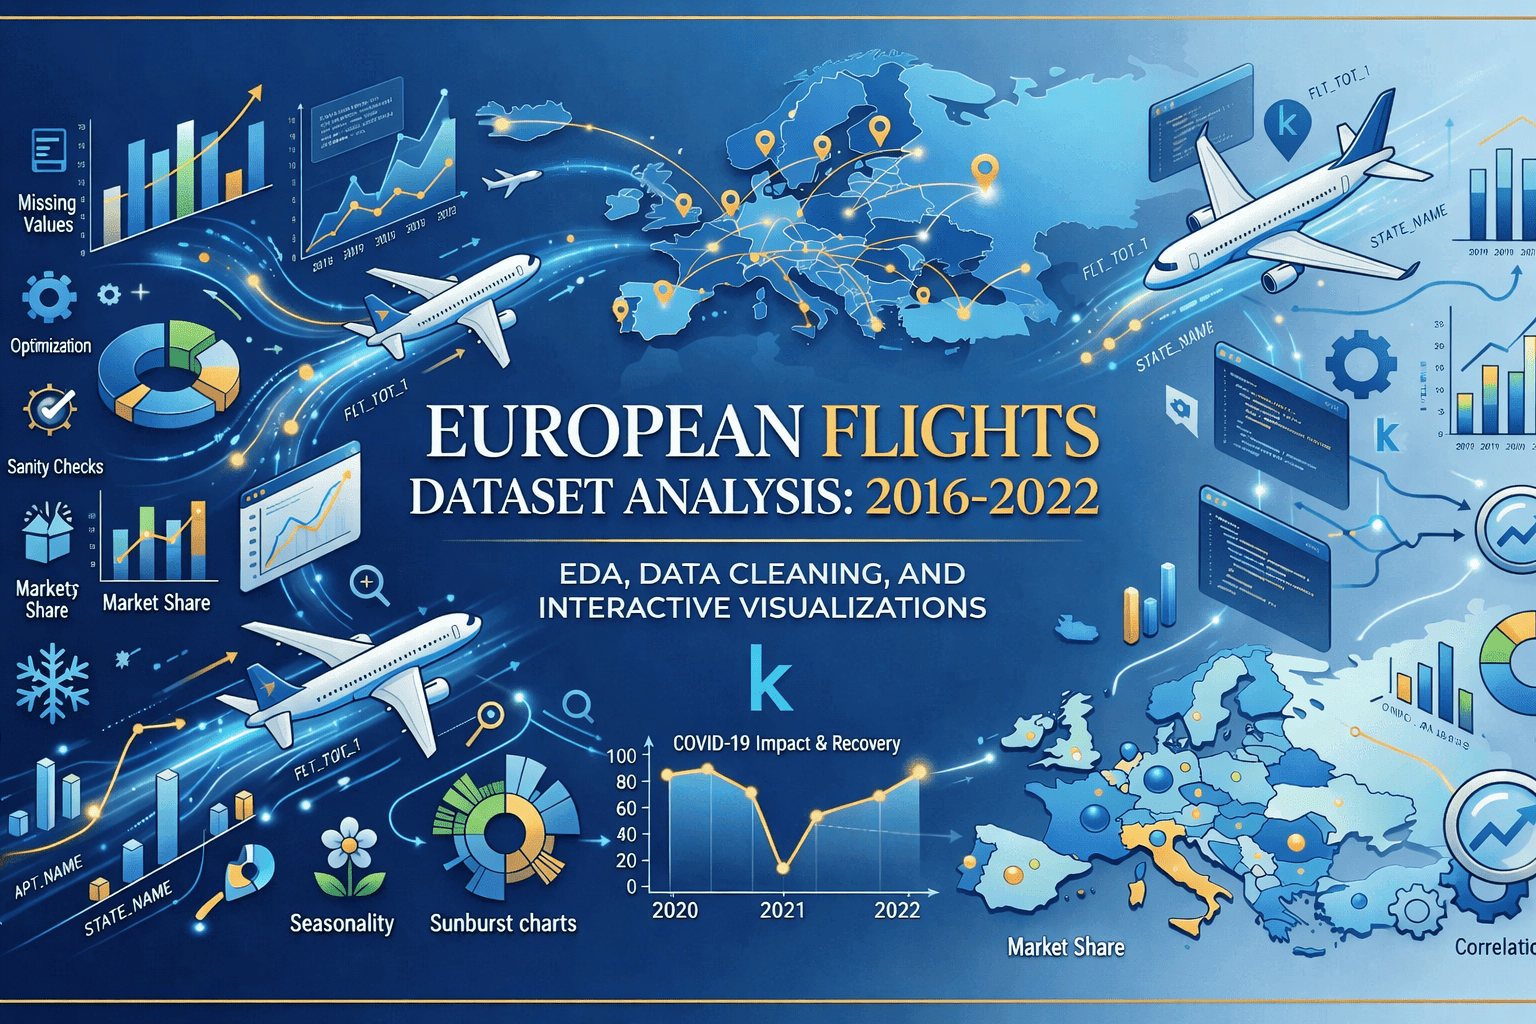

In [1]:
from IPython.display import Image
Image(filename='/kaggle/input/datasets/mariaeeam579/photo-dataset/Copilot_20260612_003916 (1).png', width=800)

<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 🚀 Initial Setup: Environment & Data Loading</h3>
</div>

In [2]:
import numpy as np
import pandas as pd     
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe_connected"

In [3]:
df = pd.read_csv("/kaggle/input/datasets/muqaddasejaz/european-flights-dataset/European Flights Dataset.csv")
df


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,Pivot Label
0,2016,1,JAN,2016-01-01T00:00:00Z,EBAW,Antwerp,Belgium,4,3,7,NaN,NaN,NaN,Antwerp (EBAW)
1,2016,1,JAN,2016-01-01T00:00:00Z,EBBR,Brussels,Belgium,174,171,345,174.0,161.0,335.0,Brussels (EBBR)
2,2016,1,JAN,2016-01-01T00:00:00Z,EBCI,Charleroi,Belgium,45,47,92,45.0,45.0,90.0,Charleroi (EBCI)
3,2016,1,JAN,2016-01-01T00:00:00Z,EBLG,Liège,Belgium,6,7,13,NaN,NaN,NaN,Liège (EBLG)
4,2016,1,JAN,2016-01-01T00:00:00Z,EBOS,Ostend-Bruges,Belgium,7,7,14,NaN,NaN,NaN,Ostend-Bruges (EBOS)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688094,2022,5,MAY,2022-05-31T00:00:00Z,LYBE,Belgrade - Nikola Tesla,Serbia,80,85,165,NaN,NaN,NaN,Belgrade - Nikola Tesla (LYBE)
688095,2022,5,MAY,2022-05-31T00:00:00Z,LYPG,Podgorica,Montenegro,19,18,37,NaN,NaN,NaN,Podgorica (LYPG)
688096,2022,5,MAY,2022-05-31T00:00:00Z,LZIB,Bratislava,Slovakia,21,21,42,20.0,19.0,39.0,Bratislava (LZIB)
688097,2022,5,MAY,2022-05-31T00:00:00Z,UDYZ,Yerevan,Armenia,39,40,79,NaN,NaN,NaN,Yerevan (UDYZ)


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 📊 Dataset Features Overview</h3>
    <ul style="color: #0A2F35; line-height: 1.8; font-size: 15px; font-weight: 500;">
        <li><b>YEAR:</b> Flight year (2016 to 2022).</li>
        <li><b>MONTH_NUM / MONTH_MON:</b> Month represented as a number (e.g., 01) and abbreviation (e.g., JAN).</li>
        <li><b>FLT_DATE:</b> Exact date of the flight movements.</li>
        <li><b>APT_ICAO:</b> 4-letter International Civil Aviation Organization airport code.</li>
        <li><b>APT_NAME:</b> Full name of the airport.</li>
        <li><b>STATE_NAME:</b> Name of the country where the airport is located.</li>
        <li><b>FLT_DEP_1:</b> Total number of departure flights.</li>
        <li><b>FLT_ARR_1:</b> Total number of arrival flights.</li>
        <li><b>FLT_TOT_1:</b> Total flight movements (departures + arrivals).</li>
        <li><b>FLT_DEP_IFR_2:</b> Instrument Flight Rules (IFR) departures (flights guided by instruments).</li>
        <li><b>FLT_ARR_IFR_2:</b> Instrument Flight Rules (IFR) arrivals.</li>
        <li><b>FLT_TOT_IFR_2:</b> Total IFR flight movements.</li>
        <li><b>Pivot Label:</b> Reference string combining airport name and code.</li>
    </ul>
</div>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688099 entries, 0 to 688098
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           688099 non-null  int64  
 1   MONTH_NUM      688099 non-null  int64  
 2   MONTH_MON      688099 non-null  object 
 3   FLT_DATE       688099 non-null  object 
 4   APT_ICAO       688099 non-null  object 
 5   APT_NAME       688099 non-null  object 
 6   STATE_NAME     688099 non-null  object 
 7   FLT_DEP_1      688099 non-null  int64  
 8   FLT_ARR_1      688099 non-null  int64  
 9   FLT_TOT_1      688099 non-null  int64  
 10  FLT_DEP_IFR_2  208314 non-null  float64
 11  FLT_ARR_IFR_2  208314 non-null  float64
 12  FLT_TOT_IFR_2  208314 non-null  float64
 13  Pivot Label    688099 non-null  object 
dtypes: float64(3), int64(5), object(6)
memory usage: 73.5+ MB


In [5]:
df.describe()

,YEAR,MONTH_NUM,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
count,688099.000000,688099.000000,688099.000000,688099.000000,688099.000000,208314.000000,208314.000000,208314.000000
mean,2018.823684,6.301461,63.238884,63.278576,126.517460,143.703097,143.610530,287.313628
std,1.841191,3.460197,110.738988,110.707515,221.415893,153.594306,153.359483,306.855582
min,2016.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.000000,5.000000,5.000000,10.000000,38.000000,38.000000,76.000000
50%,2019.000000,6.000000,17.000000,17.000000,35.000000,91.000000,91.000000,182.000000
75%,2020.000000,9.000000,71.000000,71.000000,141.000000,195.000000,195.000000,390.000000
max,2022.000000,12.000000,847.000000,813.000000,1628.000000,1039.000000,817.000000,1624.000000


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 📈 Statistical Summary Insights</h3>
    <ul style="color: #0A2F35; line-height: 1.8; font-size: 15px; font-weight: 500;">
        <li><b>Highly Skewed Traffic:</b> The average total daily flights per airport is ~126, yet the maximum reaches 1,628. This massive gap between the 75th percentile (141) and the maximum indicates that a few major "Hub" airports handle the vast majority of European air traffic.</li>
        <li><b>Perfect Operational Balance:</b> The mean daily departures (63.23) and arrivals (63.27) are almost identical, reflecting a perfectly balanced aviation network.</li>
        <li><b>Missing Data Highlight:</b> The standard flight columns contain 688,099 records, whereas the IFR (Instrument Flight Rules) columns contain only 208,314. This explicitly signals the need for Missing Value Handling in our next step.</li>
    </ul>
</div>

In [6]:
df.isnull().sum()

YEAR                  0
MONTH_NUM             0
MONTH_MON             0
FLT_DATE              0
APT_ICAO              0
APT_NAME              0
STATE_NAME            0
FLT_DEP_1             0
FLT_ARR_1             0
FLT_TOT_1             0
FLT_DEP_IFR_2    479785
FLT_ARR_IFR_2    479785
FLT_TOT_IFR_2    479785
Pivot Label           0
dtype: int64

In [7]:
missing_data = df.isnull().sum().reset_index()
missing_data.columns = ['Column', 'Missing Values']
missing_data = missing_data[missing_data['Missing Values'] > 0]

if not missing_data.empty:
    fig = px.bar(missing_data, 
                 x='Column', 
                 y='Missing Values', 
                 text='Missing Values',
                 title='<b>Missing Values Count per Column</b>',
                 color_discrete_sequence=['#89CFF0']) 
    
    fig.update_traces(textposition='outside', marker_line_color='#2C3E50', marker_line_width=1.5)
    fig.update_layout(
        xaxis_title="Columns",
        yaxis_title="Number of Missing Values",
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(family="Arial", size=14, color="#2C3E50")
    )
    fig.show()
else:
    print("No missing values found! The dataset is clean.")


df.fillna(0, inplace=True)


print("\nTotal missing values after cleaning:", df.isnull().sum().sum())


Total missing values after cleaning: 0


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 🛠️ Handling Missing Values</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        In this section, we will explore the dataset to identify any missing values (NaNs). Visualizing missing data helps us decide the best imputation strategy. Since the missing values are likely in the IFR flight counts, we will fill them with <strong>0</strong> to indicate no recorded IFR flights for those specific instances, ensuring our numerical analysis remains accurate.
    </p>
</div>

In [8]:
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'])

cols_to_int = ['FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2']
df[cols_to_int] = df[cols_to_int].astype(int)

df.drop_duplicates(inplace=True)


In [9]:
display(df.head())
display(df.info())

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,Pivot Label
0,2016,1,JAN,2016-01-01 00:00:00+00:00,EBAW,Antwerp,Belgium,4,3,7,0,0,0,Antwerp (EBAW)
1,2016,1,JAN,2016-01-01 00:00:00+00:00,EBBR,Brussels,Belgium,174,171,345,174,161,335,Brussels (EBBR)
2,2016,1,JAN,2016-01-01 00:00:00+00:00,EBCI,Charleroi,Belgium,45,47,92,45,45,90,Charleroi (EBCI)
3,2016,1,JAN,2016-01-01 00:00:00+00:00,EBLG,Liège,Belgium,6,7,13,0,0,0,Liège (EBLG)
4,2016,1,JAN,2016-01-01 00:00:00+00:00,EBOS,Ostend-Bruges,Belgium,7,7,14,0,0,0,Ostend-Bruges (EBOS)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688099 entries, 0 to 688098
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   YEAR           688099 non-null  int64              
 1   MONTH_NUM      688099 non-null  int64              
 2   MONTH_MON      688099 non-null  object             
 3   FLT_DATE       688099 non-null  datetime64[ns, UTC]
 4   APT_ICAO       688099 non-null  object             
 5   APT_NAME       688099 non-null  object             
 6   STATE_NAME     688099 non-null  object             
 7   FLT_DEP_1      688099 non-null  int64              
 8   FLT_ARR_1      688099 non-null  int64              
 9   FLT_TOT_1      688099 non-null  int64              
 10  FLT_DEP_IFR_2  688099 non-null  int64              
 11  FLT_ARR_IFR_2  688099 non-null  int64              
 12  FLT_TOT_IFR_2  688099 non-null  int64              
 13  Pivot Label    688099 non-nul

None

In [10]:
df.rename(columns={'Pivot Label': 'Airport_Label'}, inplace=True)

In [11]:
df[['FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2']].lt(0).sum()

FLT_DEP_1        0
FLT_ARR_1        0
FLT_TOT_1        0
FLT_DEP_IFR_2    0
FLT_ARR_IFR_2    0
FLT_TOT_IFR_2    0
dtype: int64

In [12]:
df['YEAR'].value_counts()

YEAR
2019    113975
2018    113466
2021    113194
2020    107055
2016     96597
2017     96589
2022     47223
Name: count, dtype: int64

In [13]:
df['MONTH_MON'].value_counts()

MONTH_MON
JAN    63638
MAR    63432
MAY    63194
APR    60138
FEB    58687
OCT    55365
JUL    55280
AUG    55136
SEP    53665
DEC    53537
JUN    53045
NOV    52982
Name: count, dtype: int64

In [14]:
df['APT_NAME'].value_counts()

APT_NAME
Tbilisi                    2343
Belgrade - Nikola Tesla    2343
Zürich                     2343
Ankara - Esenboğa          2343
Geneva                     2343
                           ... 
Valencia - Requena          456
Ciudad Real Central         366
Sligo                       223
Ventspils                    52
Tukums Jurmala               23
Name: count, Length: 333, dtype: int64

In [15]:
df['STATE_NAME'].value_counts()

STATE_NAME
France                         138694
Spain                          110164
Norway                          70174
United Kingdom                  43504
Germany                         36774
Poland                          32230
Italy                           30400
Greece                          29041
Portugal                        23795
Ireland                         16753
Austria                         13900
Türkiye                         12976
Belgium                         11672
Netherlands                     10818
Morocco                          9359
Czech Republic                   9002
Lithuania                        8964
Sweden                           7017
Switzerland                      6962
Slovenia                         6276
Romania                          4641
Cyprus                           4617
Estonia                          4368
Latvia                           3717
Croatia                          3349
Finland                          2343
L

In [16]:
df['_check'] = df['FLT_DEP_1'] + df['FLT_ARR_1']
inconsistent = df[df['FLT_TOT_1'] != df['_check']]

print(f"Inconsistent rows: {len(inconsistent)}")
print(f"Percentage: {len(inconsistent)/len(df)*100:.2f}%")

if len(inconsistent) > 0:
    display(inconsistent[['FLT_DATE','APT_NAME','FLT_DEP_1','FLT_ARR_1','FLT_TOT_1','_check']].head(10))
    inconsistent['_diff'] = inconsistent['FLT_TOT_1'] - inconsistent['_check']
    print(inconsistent['_diff'].describe())

df.drop(columns=['_check'], inplace=True)

Inconsistent rows: 0
Percentage: 0.00%


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);">🔍 Data Integrity & Consistency Check</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        A crucial step in advanced data cleaning is verifying internal mathematical consistency. In this block, we validate the fundamental equation: <code>Total Flights = Arrivals + Departures</code>. By isolating any rows that violate this rule, we can identify potential recording anomalies or miscalculations, ensuring our downstream analysis is built on a 100% accurate and logically sound foundation.
    </p>
</div>

In [17]:
yearly_flights = df.groupby('YEAR')['FLT_TOT_1'].sum().reset_index()
display(yearly_flights)

,YEAR,FLT_TOT_1
0,2016,15255741
1,2017,15798638
2,2018,17020118
3,2019,17185911
4,2020,7417016
5,2021,9252593
6,2022,5126521


In [18]:
df['Day_of_Week'] = pd.to_datetime(df['FLT_DATE']).dt.day_name()

weekly_traffic = df.groupby('Day_of_Week')['FLT_TOT_1'].sum().sort_values(ascending=False).reset_index()
display(weekly_traffic)

,Day_of_Week,FLT_TOT_1
0,Friday,13406480
1,Thursday,12877742
2,Monday,12840085
3,Wednesday,12534891
4,Tuesday,12197968
5,Sunday,12172856
6,Saturday,11026516


In [19]:
monthly_traffic = df.groupby('MONTH_MON')['FLT_TOT_1'].sum().sort_values(ascending=False).reset_index()
display(monthly_traffic)

,MONTH_MON,FLT_TOT_1
0,AUG,8236009
1,JUL,8063220
2,SEP,7922637
3,MAY,7902728
4,OCT,7577217
5,MAR,7185807
6,APR,7106667
7,JUN,7087768
8,JAN,6982208
9,FEB,6655653


In [20]:
season_map = {
    'DEC': 'Winter', 'JAN': 'Winter', 'FEB': 'Winter',
    'MAR': 'Spring', 'APR': 'Spring', 'MAY': 'Spring',
    'JUN': 'Summer', 'JUL': 'Summer', 'AUG': 'Summer',
    'SEP': 'Autumn', 'OCT': 'Autumn', 'NOV': 'Autumn'
}

df['Season'] = df['MONTH_MON'].map(season_map)

seasonal_traffic = df.groupby('Season')['FLT_TOT_1'].sum().sort_values(ascending=False).reset_index()
display(seasonal_traffic)

,Season,FLT_TOT_1
0,Summer,23386997
1,Spring,22195202
2,Autumn,21700359
3,Winter,19773980


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 🌤️ Seasonal Traffic Analysis & Feature Engineering</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        Flight volumes are highly influenced by the time of year. By engineering a new <code>Season</code> feature based on the meteorological calendar, we can aggregate the total flight traffic to clearly identify peak travel periods. This analysis is crucial for understanding seasonal demand variations, such as the massive surge in air traffic during the European Summer holidays.
    </p>
</div>

In [21]:
top_airports = df.groupby('APT_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10).reset_index()
display(top_airports)

,APT_NAME,FLT_TOT_1
0,Amsterdam - Schiphol,2694025
1,Paris-Charles-de-Gaulle,2581673
2,Frankfurt,2581524
3,London - Heathrow,2446474
4,Madrid - Barajas,2117063
5,Munich,2013524
6,Barcelona,1699766
7,Istanbul Atatürk,1570488
8,Rome - Fiumicino,1518100
9,Zürich,1372321


In [22]:
top_countries = df.groupby('STATE_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10).reset_index()
display(top_countries)

,STATE_NAME,FLT_TOT_1
0,Spain,10858755
1,Germany,10710416
2,United Kingdom,10571729
3,France,9980740
4,Italy,6286032
5,Türkiye,5680924
6,Norway,3620616
7,Netherlands,2958470
8,Greece,2647744
9,Switzerland,2371676


In [23]:
busiest_dates = df.groupby('FLT_DATE')['FLT_TOT_1'].sum().sort_values(ascending=False).reset_index().head(5)
display(busiest_dates)

,FLT_DATE,FLT_TOT_1
0,2019-07-05 00:00:00+00:00,57008
1,2019-06-28 00:00:00+00:00,56916
2,2018-09-07 00:00:00+00:00,56765
3,2019-08-30 00:00:00+00:00,56490
4,2019-06-14 00:00:00+00:00,56466


In [24]:
state_traffic = df.groupby('STATE_NAME')[['FLT_ARR_1', 'FLT_DEP_1']].sum().reset_index()
top_arrivals = state_traffic.sort_values(by='FLT_ARR_1', ascending=False).head(5)
top_departures = state_traffic.sort_values(by='FLT_DEP_1', ascending=False).head(5)
display(top_arrivals)
display(top_departures)

,STATE_NAME,FLT_ARR_1,FLT_DEP_1
36,Spain,5429141,5429614
14,Germany,5362547,5347869
41,United Kingdom,5286524,5285205
12,France,4993174,4987566
19,Italy,3143353,3142679


,STATE_NAME,FLT_ARR_1,FLT_DEP_1
36,Spain,5429141,5429614
14,Germany,5362547,5347869
41,United Kingdom,5286524,5285205
12,France,4993174,4987566
19,Italy,3143353,3142679


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> Perfect Operational Balance: Arrivals vs. Departures</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        When we extract the top 5 countries for incoming flights and compare them to the top 5 for outgoing flights, we see identical results: <b>Spain, Germany, the UK, France, and Italy</b> dominate both lists. Furthermore, the numbers for arrivals and departures within each country are nearly perfectly matched. This beautifully illustrates the concept of <strong>Perfect Operational Balance</strong> in aviation—every aircraft that arrives at a destination must eventually depart. This perfect symmetry confirms both the logical flow of the aviation business and the high integrity of our 7-year dataset.
    </p>
</div>

In [25]:
ifr_traffic = df.groupby('Airport_Label')[['FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2']].sum().reset_index()
top_ifr_airports = ifr_traffic.sort_values(by='FLT_TOT_IFR_2', ascending=False).head(5)
display(top_ifr_airports)

,Airport_Label,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
12,Amsterdam - Schiphol (EHAM),1346033,1345682,2691715
97,Frankfurt (EDDF),1271780,1271633,2543413
223,Paris-Charles-de-Gaulle (LFPG),1254861,1252335,2507196
167,London - Heathrow (EGLL),1166010,1166755,2332765
179,Madrid - Barajas (LEMD),1032253,1030780,2063033


In [26]:
flights_2019 = df[df['YEAR'] == 2019]['FLT_TOT_1'].sum()
flights_2020 = df[df['YEAR'] == 2020]['FLT_TOT_1'].sum()
drop_percentage = ((flights_2019 - flights_2020) / flights_2019) * 100

print(f"Total flights in 2019: {flights_2019:,}")
print(f"Total flights in 2020: {flights_2020:,}")
print(f"Flight traffic dropped by {drop_percentage:.2f}% in 2020 due to COVID-19.")

Total flights in 2019: 17,185,911
Total flights in 2020: 7,417,016
Flight traffic dropped by 56.84% in 2020 due to COVID-19.


In [27]:
df_years = df[df['YEAR'].isin([2019, 2020, 2021])]

pivot_covid = df_years.pivot_table(index='STATE_NAME', columns='YEAR', values='FLT_TOT_1', aggfunc='sum').reset_index()

pivot_covid.columns.name = None

pivot_covid['Drop_2020_(%)'] = round(((pivot_covid[2019] - pivot_covid[2020]) / pivot_covid[2019]) * 100, 2)

pivot_covid['Recovery_2021_(%)'] = round((pivot_covid[2021] / pivot_covid[2019]) * 100, 2)

covid_analysis = pivot_covid.sort_values(by='Recovery_2021_(%)', ascending=False)

display(covid_analysis[['STATE_NAME', 2019, 2020, 2021, 'Drop_2020_(%)', 'Recovery_2021_(%)']].head(10))

,STATE_NAME,2019,2020,2021,Drop_2020_(%),Recovery_2021_(%)
0,Albania,28500,15288,26190,46.36,91.89
4,Bosnia and Herzegovina,12918,5383,10681,58.33,82.68
1,Armenia,25556,9373,19439,63.32,76.06
15,Greece,508450,229559,370780,54.85,72.92
31,Republic of North Macedonia,18845,8250,13327,56.22,70.72
28,Norway,726795,469920,507141,35.34,69.78
39,Türkiye,1060929,492743,738132,53.56,69.57
33,Serbia,70978,34129,49367,51.92,69.55
40,Ukraine,111042,46973,75817,57.70,68.28
5,Bulgaria,60266,34984,39888,41.95,66.19


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);">🌍 Country-Level Resilience & Recovery Analysis</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        While our previous analysis revealed the macro-level impact of the pandemic, this Pivot Table dives deeper into the micro-level resilience of individual nations. By calculating the exact percentage drop in 2020 and the subsequent recovery rate in 2021 relative to the 2019 baseline, we can rank European countries based on how quickly their aviation sectors bounced back from the global crisis.
    </p>
</div>

In [28]:
covid = df.groupby('YEAR')['FLT_TOT_1'].sum().reset_index()
covid.columns = ['YEAR', 'TOTAL_FLIGHTS']

baseline = covid.loc[covid['YEAR'] == 2019, 'TOTAL_FLIGHTS'].values[0]
covid['VS_2019_%'] = ((covid['TOTAL_FLIGHTS'] - baseline) / baseline * 100).round(2)

print(covid.to_string(index=False))

 YEAR  TOTAL_FLIGHTS  VS_2019_%
 2016       15255741     -11.23
 2017       15798638      -8.07
 2018       17020118      -0.96
 2019       17185911       0.00
 2020        7417016     -56.84
 2021        9252593     -46.16
 2022        5126521     -70.17


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);">🦠 COVID-19 Impact & True Recovery Tracking</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        The most critical insight in this analysis is the use of <strong>2019 as a baseline</strong>. Instead of calculating standard year-over-year growth—which would show a misleadingly massive surge in 2021—anchoring our data to the pre-pandemic peak reveals the <em>true</em> scale of the aviation collapse in 2020. More importantly, it accurately measures the industry's ongoing recovery rate toward normal operational levels.
    </p>
</div>

In [29]:
country_total = df.groupby('STATE_NAME')['FLT_TOT_1'].sum()
airport_total = df.groupby(['STATE_NAME', 'APT_NAME'])['FLT_TOT_1'].sum()

market_share = airport_total / country_total * 100
market_share = market_share.reset_index()
market_share.columns = ['STATE_NAME', 'APT_NAME', 'MARKET_SHARE_%']
market_share = market_share.sort_values(['STATE_NAME', 'MARKET_SHARE_%'], ascending=[True, False])

print(market_share.groupby('STATE_NAME').head(3).to_string(index=False))

                 STATE_NAME                            APT_NAME  MARKET_SHARE_%
                    Albania                              Tirana      100.000000
                    Armenia                             Yerevan      100.000000
                    Austria                              Vienna       74.258908
                    Austria                            Salzburg        8.564932
                    Austria                           Innsbruck        5.726284
                    Belgium                            Brussels       64.644282
                    Belgium                           Charleroi       15.828235
                    Belgium                               Liège       12.542415
     Bosnia and Herzegovina                            Sarajevo      100.000000
                   Bulgaria                               Sofia      100.000000
                    Croatia                              Zagreb       98.160840
                    Croatia             

<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);">🏢 Domestic Market Share Analysis</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        To understand the concentration of air traffic within individual nations, we calculate the market share of each airport relative to its country's total flights. By isolating the top 3 airports per state, this analysis reveals whether a country's aviation network relies heavily on a single dominant monopoly or is distributed across multiple regional hubs.
    </p>
</div>

In [30]:
airport_ifr = df.groupby('APT_NAME').agg(
    TOTAL_FLIGHTS=('FLT_TOT_1', 'sum'),
    TOTAL_IFR=('FLT_TOT_IFR_2', 'sum')
).reset_index()

airport_ifr['IFR_RATIO_%'] = (airport_ifr['TOTAL_IFR'] / airport_ifr['TOTAL_FLIGHTS'] * 100).round(2)
airport_ifr = airport_ifr.sort_values('IFR_RATIO_%', ascending=False)

print("Top 10 airports by IFR ratio:")
print(airport_ifr.head(10).to_string(index=False))

print("\nCorrelation between airport size and IFR ratio:")
print(airport_ifr[['TOTAL_FLIGHTS', 'IFR_RATIO_%']].corr())

Top 10 airports by IFR ratio:
            APT_NAME  TOTAL_FLIGHTS  TOTAL_IFR  IFR_RATIO_%
               Malta         283622     300853       106.08
              Bremen         158801     166129       104.61
             Tallinn         223169     230281       103.19
   Helsinki - Vantaa         929047     945367       101.76
            Brussels        1178495    1191305       101.09
              Dublin        1161078    1162688       100.14
           Edinburgh         632849     632921       100.01
    Rome - Fiumicino        1518100    1517464        99.96
Amsterdam - Schiphol        2694025    2691715        99.91
 Budapest - Ferihegy         572817     568672        99.28

Correlation between airport size and IFR ratio:
               TOTAL_FLIGHTS  IFR_RATIO_%
TOTAL_FLIGHTS        1.00000      0.62098
IFR_RATIO_%          0.62098      1.00000


<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);">🛩️ IFR Ratio & Airport Scale Correlation</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        To measure an airport's reliance on advanced navigational operations, we calculate the Instrument Flight Rules (IFR) ratio. By identifying the top airports with the highest IFR percentages, we can see which facilities are most dependent on technical flight guidance. Furthermore, the correlation matrix statistically tests a critical hypothesis: does the overall traffic volume of an airport naturally dictate a higher dependency on IFR systems?
    </p>
</div>

In [31]:
top_airports_map = df.groupby('APT_NAME')['FLT_TOT_1'].sum().reset_index().sort_values('FLT_TOT_1', ascending=False).head(10)


coords = {
    'Amsterdam - Schiphol': {'lat': 52.3105, 'lon': 4.7683},
    'Paris-Charles-de-Gaulle': {'lat': 49.0097, 'lon': 2.5479},
    'Frankfurt': {'lat': 50.0333, 'lon': 8.5706},
    'London - Heathrow': {'lat': 51.4700, 'lon': -0.4543},
    'Madrid - Barajas': {'lat': 40.4983, 'lon': -3.5676},
    'Munich': {'lat': 48.3537, 'lon': 11.7861},
    'Barcelona': {'lat': 41.2974, 'lon': 2.0833},
    'Istanbul Atatürk': {'lat': 40.9769, 'lon': 28.8146},
    'Rome - Fiumicino': {'lat': 41.7999, 'lon': 12.2462},
    'Zürich': {'lat': 47.4647, 'lon': 8.5492}
}

top_airports_map['Latitude'] = top_airports_map['APT_NAME'].apply(lambda x: coords.get(x, {}).get('lat', 0))
top_airports_map['Longitude'] = top_airports_map['APT_NAME'].apply(lambda x: coords.get(x, {}).get('lon', 0))


fig = px.scatter_geo(
    top_airports_map,
    lat='Latitude',
    lon='Longitude',
    size='FLT_TOT_1',
    hover_name='APT_NAME',
    scope='europe', 
    title='<b>Top 10 Busiest Airports on the Map</b>',
    color='FLT_TOT_1',
    color_continuous_scale='Blues', 
    size_max=40 
)


fig.update_layout(
    geo=dict(
        showframe=False, 
        showcoastlines=True, 
        projection_type='natural earth', 
        bgcolor='rgba(0,0,0,0)'
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    margin=dict(t=60, l=0, r=0, b=0)
)

fig.show()

<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 📍 Top 10 Busiest Airports Mapping</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        To visualize the spatial distribution of air traffic, we enrich our dataset with the exact geographical coordinates (Latitude and Longitude) of the top 10 busiest European airports. This interactive bubble map highlights the continent's major aviation hubs, with the size of each bubble perfectly proportional to its total flight volume, instantly drawing attention to massive transit points like Schiphol, Charles de Gaulle, and Heathrow.
    </p>
</div>

In [32]:
seasonal_traffic = df.groupby('Season')['FLT_TOT_1'].sum().sort_values(ascending=False).reset_index()


fig = px.bar(
    seasonal_traffic, 
    x='Season', 
    y='FLT_TOT_1', 
    text='FLT_TOT_1', 
    title='<b>Total Flight Traffic by Season</b>',
    color='Season', 
  
    color_discrete_map={
        'Summer': '#F39C12', 
        'Spring': '#27AE60', 
        'Autumn': '#D35400', 
        'Winter': '#89CFF0'
    }
)


fig.update_traces(
    texttemplate='%{text:.2s}', 
    textposition='outside', 
    marker_line_color='#2C3E50', 
    marker_line_width=1.5
)

fig.update_layout(
    xaxis_title="<b>Season</b>",
    yaxis_title="<b>Total Flights</b>",
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    showlegend=False, 
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

In [33]:
fig = px.line(
    yearly_flights, 
    x='YEAR', 
    y='FLT_TOT_1', 
    title='<b>Yearly Flight Traffic Trend (2016-2022)</b>',
    markers=True,
    line_shape='spline',
    color_discrete_sequence=['#89CFF0']
)

fig.update_traces(
    marker=dict(size=12, color='#2C3E50', line=dict(width=2, color='#89CFF0')),
    line=dict(width=4)
)

fig.update_layout(
    xaxis_title="<b>Year</b>",
    yaxis_title="<b>Total Flights</b>",
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    xaxis=dict(showgrid=False, tickmode='linear'),
    yaxis=dict(showgrid=True, gridcolor='#E8F3FA'),
    margin=dict(t=60, l=20, r=20, b=20)
)

fig.show()

In [34]:
fig1 = px.bar(
    covid,
    x='YEAR',
    y='VS_2019_%',
    text='VS_2019_%',
    title='<b>Flight Traffic Percentage Change (Base Year: 2019)</b>',
    color='VS_2019_%',
    color_continuous_scale=px.colors.diverging.RdBu
)

fig1.update_traces(
    texttemplate='%{text}%', 
    textposition='outside',
    marker_line_color='#2C3E50',
    marker_line_width=1.5
)

fig1.add_hline(y=0, line_dash="solid", line_color="#2C3E50", line_width=2)

fig1.update_layout(
    xaxis_title="<b>Year</b>",
    yaxis_title="<b>% Difference from 2019</b>",
    coloraxis_showscale=False,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    margin=dict(t=60, l=20, r=20, b=20)
)

fig1.show()

In [35]:
top_5_countries = df.groupby('STATE_NAME')['FLT_TOT_1'].sum().nlargest(5).index
top_ms_data = market_share[market_share['STATE_NAME'].isin(top_5_countries)].groupby('STATE_NAME').head(3)

fig2 = px.bar(
    top_ms_data,
    x='STATE_NAME',
    y='MARKET_SHARE_%',
    color='APT_NAME',
    title='<b>Top 3 Airports Market Share within Top 5 Countries</b>',
    text='MARKET_SHARE_%',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig2.update_traces(
    texttemplate='%{text:.1f}%', 
    textposition='inside',
    marker_line_color='#2C3E50',
    marker_line_width=1
)

fig2.update_layout(
    barmode='stack',
    xaxis_title="<b>Country</b>",
    yaxis_title="<b>Market Share (%)</b>",
    legend_title="<b>Airport</b>",
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    margin=dict(t=60, l=20, r=20, b=20)
)

fig2.show()

In [36]:
filtered_airport_ifr = airport_ifr[airport_ifr['TOTAL_FLIGHTS'] > 5000] 

fig3 = px.scatter(
    filtered_airport_ifr,
    x='TOTAL_FLIGHTS',
    y='IFR_RATIO_%',
    size='TOTAL_IFR',
    hover_name='APT_NAME',
    title='<b>Correlation: Total Flights vs. IFR Ratio</b>',
    color='IFR_RATIO_%',
    color_continuous_scale='Blues',
    size_max=40
)

fig3.update_layout(
    xaxis_title="<b>Total Flights (Airport Size)</b>",
    yaxis_title="<b>IFR Flights Ratio (%)</b>",
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=14, color="#2C3E50"),
    margin=dict(t=60, l=20, r=20, b=20)
)

fig3.show()

<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 📈 Correlation: Airport Size vs. IFR Ratio</h3>
    <p style="color: #0A2F35; line-height: 1.6; font-size: 15px; font-weight: 500;">
        Is there a relationship between the overall traffic volume of an airport and its reliance on Instrument Flight Rules (IFR)? By filtering for significant airports (over 5,000 total flights) and mapping them on this interactive scatter plot, we can visualize this correlation. Larger bubbles represent airports with massive IFR operations, helping us instantly spot patterns between an airport's scale and its dependency on technical flight guidance.
    </p>
</div>

<div style="background-color: #E8FFFF; padding: 20px; border-radius: 12px; border-left: 8px solid #00F0FF; font-family: sans-serif; box-shadow: 0 0 20px rgba(0, 240, 255, 0.6), inset 0 0 10px rgba(0, 240, 255, 0.2);">
    <h3 style="color: #005F73; margin-top: 0; text-shadow: 0 0 8px rgba(0, 240, 255, 0.8);"> 🎯 Executive Summary & Key Takeaways</h3>
    <ul style="color: #0A2F35; line-height: 1.8; font-size: 15px; font-weight: 500;">
        <li><b>High Concentration:</b> A small number of massive hubs (like those in Spain, Germany, and the UK) monopolize the majority of European air traffic, demonstrating a perfectly balanced arrival/departure ecosystem.</li>
        <li><b>Technical Dependency:</b> There is a strong, positive correlation between the sheer size of an airport and its reliance on Instrument Flight Rules (IFR), confirming that major hubs depend heavily on advanced navigational systems.</li>
        <li><b>Pandemic Resilience:</b> Grounding our data against the 2019 baseline revealed the catastrophic impact of 2020. More importantly, country-level analysis highlighted diverse recovery rates in 2021, proving that not all aviation sectors bounced back with the same agility.</li>
    </ul>
</div>

In [37]:
df

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,Airport_Label,Day_of_Week,Season
0,2016,1,JAN,2016-01-01 00:00:00+00:00,EBAW,Antwerp,Belgium,4,3,7,0,0,0,Antwerp (EBAW),Friday,Winter
1,2016,1,JAN,2016-01-01 00:00:00+00:00,EBBR,Brussels,Belgium,174,171,345,174,161,335,Brussels (EBBR),Friday,Winter
2,2016,1,JAN,2016-01-01 00:00:00+00:00,EBCI,Charleroi,Belgium,45,47,92,45,45,90,Charleroi (EBCI),Friday,Winter
3,2016,1,JAN,2016-01-01 00:00:00+00:00,EBLG,Liège,Belgium,6,7,13,0,0,0,Liège (EBLG),Friday,Winter
4,2016,1,JAN,2016-01-01 00:00:00+00:00,EBOS,Ostend-Bruges,Belgium,7,7,14,0,0,0,Ostend-Bruges (EBOS),Friday,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688094,2022,5,MAY,2022-05-31 00:00:00+00:00,LYBE,Belgrade - Nikola Tesla,Serbia,80,85,165,0,0,0,Belgrade - Nikola Tesla (LYBE),Tuesday,Spring
688095,2022,5,MAY,2022-05-31 00:00:00+00:00,LYPG,Podgorica,Montenegro,19,18,37,0,0,0,Podgorica (LYPG),Tuesday,Spring
688096,2022,5,MAY,2022-05-31 00:00:00+00:00,LZIB,Bratislava,Slovakia,21,21,42,20,19,39,Bratislava (LZIB),Tuesday,Spring
688097,2022,5,MAY,2022-05-31 00:00:00+00:00,UDYZ,Yerevan,Armenia,39,40,79,0,0,0,Yerevan (UDYZ),Tuesday,Spring
